# Livrable 2 — Construction d'un premier reseau de neurones


### Plan
1. Choix de l'architecture reseau
4. Construction du reseau de neurones
5. Entrainement et evaluation
6. Comparaison de toutes les configurations



---
## 1. Imports & Configuration


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score
)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
sns.set_theme(style='whitegrid')

print('Imports OK')
print(f'TensorFlow : {tf.__version__}')


Imports OK
TensorFlow : 2.21.0


---
## 2. Chargement & Pretraitement des Donnees


| Caracteristique | Valeur |
|---|---|
| Observations | 70 692 |
| Features | 21 indicateurs de sante |
| Cible | `Diabetes_binary` (0 = non diabetique, 1 = diabetique) |
| Desequilibre | ~86% / 14% — corrige par SMOTE |

**Etapes :**
- Split stratifie 75% train / 25% test
- Normalisation StandardScaler (fit sur train uniquement)
- SMOTE sur train uniquement (jamais sur le test)


In [9]:
# Datasets générés par 01_preprocessing.ipynb
TRAIN_PATH = 'data/processed/train.parquet'
TEST_PATH = 'data/processed/test.parquet'

train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)

df_preview = pd.concat([train_df.assign(split='train'), test_df.assign(split='test')], ignore_index=True)

print(f'Train shape : {train_df.shape}')
print(f'Test shape  : {test_df.shape}')
print('Distribution cible (train) :')
print(train_df['Diabetes_binary'].value_counts())
print(f'Ratio desequilibre (train) : {train_df["Diabetes_binary"].value_counts()[0] / train_df["Diabetes_binary"].value_counts()[1]:.1f}:1')
df_preview.head(3)


Shape : (229474, 23)
Distribution cible :
Diabetes_binary
0.0    194377
1.0     35097
Name: count, dtype: int64
Ratio desequilibre : 5.5:1


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary,dataset
0,-0.910546,-0.88892,0.205424,-1.131939,1.070211,-0.216358,-0.339284,-1.661802,-1.256224,-1.965499,...,-0.563228,-0.455238,-0.516657,-0.477415,1.133608,0.296909,-0.988384,-2.340492,0.0,train
1,1.098242,1.12496,0.205424,-0.836723,1.070211,4.621976,-0.339284,0.601756,0.796036,0.508777,...,1.315672,1.484706,2.800868,2.094614,1.133608,0.620622,-0.988384,-1.862191,0.0,train
2,1.098242,1.12496,0.205424,0.344139,-0.934395,4.621976,2.947384,0.601756,0.796036,0.508777,...,0.376222,0.191410,-0.516657,-0.477415,1.133608,0.944334,1.027092,1.007615,0.0,train


In [10]:
# Les datasets sont déjà filtrés (features sélectionnées) et normalisés
X_train_sc = train_df.drop(columns=['Diabetes_binary'])
y_train = train_df['Diabetes_binary'].astype(int)

X_test_sc = test_df.drop(columns=['Diabetes_binary'])
y_test = test_df['Diabetes_binary'].astype(int)

feature_names = X_train_sc.columns.tolist()

# =========================
# SMOTE (train uniquement)
# =========================
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

# =========================
# Infos
# =========================
print(f'Train avant SMOTE : {X_train_sc.shape[0]:,}')
print(f'Train apres SMOTE : {X_train_sm.shape[0]:,}')
print(f'Test              : {X_test_sc.shape[0]:,}')
print(f'Features          : {X_train_sm.shape[1]}')

INPUT_DIM = X_train_sm.shape[1]

Train avant SMOTE : 172,105
Train apres SMOTE : 291,564
Test              : 57,369
Features          : 21


---
## Partie 1 — Choix de l'Architecture Reseau

### Criteres de choix

| Critere | Choix | Justification |
|---|---|---|
| Type de reseau | MLP (Multilayer Perceptron) | Donnees tabulaires, pas d'image ni de sequence |
| Activation cachee | ReLU | Convergence rapide, evite la disparition du gradient |
| Activation sortie | Sigmoid | Sortie probabilite en [0,1] pour la classification binaire |
| Fonction de perte | Binary Crossentropy | Standard pour la classification binaire |
| Optimiseur | Adam | Adaptatif, robuste au choix du learning rate |
| Regularisation | Dropout + L2 | Limite le surapprentissage |
| Normalisation | BatchNormalization | Stabilise et accelere l'entrainement |

### Configurations a tester

On fait varier **le nombre de couches** et **le batch size** pour mesurer leur impact.

| Configuration | Couches cachees | Neurones | Batch size | Dropout |
|---|---|---|---|---|
| Config A | 1 | [64] | 64 | 0.3 |
| Config B | 2 | [128, 64] | 64 | 0.3 |
| Config C | 3 | [128, 64, 32] | 64 | 0.3 |
| Config D | 2 | [128, 64] | 32 | 0.3 |
| Config E | 2 | [128, 64] | 128 | 0.3 |
| Config F | 2 | [256, 128] | 64 | 0.4 |
| Config G | 3 | [128, 64, 32] | 32 | 0.4 |


In [11]:
# Definition de toutes les configurations a tester
CONFIGURATIONS = [
    {
        'nom':        'Config A — 1 couche',
        'units':      [64],
        'batch_size': 64,
        'dropout':    0.3,
        'l2':         0.001,
    },
    {
        'nom':        'Config B — 2 couches standard',
        'units':      [128, 64],
        'batch_size': 64,
        'dropout':    0.3,
        'l2':         0.001,
    },
    {
        'nom':        'Config C — 3 couches standard',
        'units':      [128, 64, 32],
        'batch_size': 64,
        'dropout':    0.3,
        'l2':         0.001,
    },
    {
        'nom':        'Config D — 2 couches petit batch',
        'units':      [128, 64],
        'batch_size': 32,
        'dropout':    0.3,
        'l2':         0.001,
    },
    {
        'nom':        'Config E — 2 couches grand batch',
        'units':      [128, 64],
        'batch_size': 128,
        'dropout':    0.3,
        'l2':         0.001,
    },
    {
        'nom':        'Config F — 2 couches larges',
        'units':      [256, 128],
        'batch_size': 64,
        'dropout':    0.4,
        'l2':         0.001,
    },
    {
        'nom':        'Config G — 3 couches dropout eleve',
        'units':      [128, 64, 32],
        'batch_size': 32,
        'dropout':    0.4,
        'l2':         0.0005,
    },
]

print(f'{len(CONFIGURATIONS)} configurations definies')
for cfg in CONFIGURATIONS:
    n = len(cfg['units'])
    print(f"  {cfg['nom']:<35} | couches={n} | units={cfg['units']} | bs={cfg['batch_size']} | dropout={cfg['dropout']}")


7 configurations definies
  Config A — 1 couche                 | couches=1 | units=[64] | bs=64 | dropout=0.3
  Config B — 2 couches standard       | couches=2 | units=[128, 64] | bs=64 | dropout=0.3
  Config C — 3 couches standard       | couches=3 | units=[128, 64, 32] | bs=64 | dropout=0.3
  Config D — 2 couches petit batch    | couches=2 | units=[128, 64] | bs=32 | dropout=0.3
  Config E — 2 couches grand batch    | couches=2 | units=[128, 64] | bs=128 | dropout=0.3
  Config F — 2 couches larges         | couches=2 | units=[256, 128] | bs=64 | dropout=0.4
  Config G — 3 couches dropout eleve  | couches=3 | units=[128, 64, 32] | bs=32 | dropout=0.4


---
## Partie 2 — Construction du Reseau de Neurones

### Architecture generale
```
Entree  : 21 features (normalisees)
   |
   v
[ Dense(n, ReLU) -> BatchNorm -> Dropout ] x n_couches
   |
   v
Dense(1, Sigmoid)  ->  P(diabetique) dans [0, 1]
```

### Role de chaque composant
- **Dense(n, ReLU)** : apprend des combinaisons non-lineaires des features
- **BatchNormalization** : normalise les activations -> convergence plus stable
- **Dropout(p)** : desactive aleatoirement p% des neurones -> evite la memorisation
- **Dense(1, Sigmoid)** : convertit la derniere representation en probabilite


In [ ]:
def build_model(units, dropout, l2, input_dim, nom='model'):
  
    model = keras.Sequential(name=nom.replace(' ', '_').replace('—', ''))
    model.add(layers.Input(shape=(input_dim,)))

    for i, n_units in enumerate(units):
        model.add(layers.Dense(
            n_units,
            kernel_regularizer=regularizers.l2(l2),
            name=f'dense_{i+1}'
        ))
        model.add(layers.BatchNormalization(name=f'bn_{i+1}'))
        model.add(layers.Activation('relu', name=f'relu_{i+1}'))
        model.add(layers.Dropout(dropout, name=f'dropout_{i+1}'))

    model.add(layers.Dense(1, activation='sigmoid', name='sortie'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ]
    )
    return model


# Verification : afficher le resume de la Config B
cfg_demo = CONFIGURATIONS[1]
model_demo = build_model(
    units=cfg_demo['units'],
    dropout=cfg_demo['dropout'],
    l2=cfg_demo['l2'],
    input_dim=INPUT_DIM,
    nom=cfg_demo['nom']
)
model_demo.summary()
print(f'\nNombre total de parametres : {model_demo.count_params():,}')


Model: "Config_B__2_couches_standard"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sortie (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 384 (1.50 KB)


Nombre total de parametres : 11,905


---
## Partie 3 — Entrainement et Evaluation

### Protocole d'entrainement
| Parametre | Valeur | Role |
|---|---|---|
| Epochs max | 80 | Plafond, rarement atteint grace a Early Stopping |
| Validation split | 20% du train | Surveille la generalisation pendant l'entrainement |
| Early Stopping | patience=10, val_loss | Arrete si pas d'amelioration -> evite l'overfitting |


Chaque configuration est entrainee independamment et evaluee sur le **meme jeu de test**.


In [13]:
# Callbacks communs a toutes les configurations
def get_callbacks():
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=0
        )
    ]


# Stockage des resultats
resultats = []
histories = {}

print('Debut de l entrainement des configurations...')
print('=' * 60)


Debut de l entrainement des configurations...


In [14]:
for cfg in CONFIGURATIONS:
    print(f"\n{cfg['nom']}")
    print('-' * 50)

    # Construction
    model = build_model(
        units=cfg['units'],
        dropout=cfg['dropout'],
        l2=cfg['l2'],
        input_dim=INPUT_DIM,
        nom=cfg['nom']
    )
    n_params = model.count_params()

    # Entrainement
    history = model.fit(
        X_train_sm, y_train_sm,
        epochs=80,
        batch_size=cfg['batch_size'],
        validation_split=0.2,
        callbacks=get_callbacks(),
        verbose=0
    )
    epochs_done = len(history.history['loss'])

    # Evaluation sur le jeu de test
    y_proba = model.predict(X_test_sc, verbose=0).flatten()
    y_pred  = (y_proba >= 0.5).astype(int)

    auc       = roc_auc_score(y_test, y_proba)
    acc       = accuracy_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    prec      = precision_score(y_test, y_pred)
    rec       = recall_score(y_test, y_pred)
    cm        = confusion_matrix(y_test, y_pred)
    fn        = cm[1, 0]
    fp        = cm[0, 1]

    # Ecart train / val (diagnostic surapprentissage)
    train_acc_final = history.history['accuracy'][-1]
    val_acc_final   = history.history['val_accuracy'][-1]
    ecart_acc       = train_acc_final - val_acc_final

    print(f'  Epochs      : {epochs_done}')
    print(f'  Parametres  : {n_params:,}')
    print(f'  AUC-ROC     : {auc:.4f}')
    print(f'  Accuracy    : {acc:.4f}')
    print(f'  F1          : {f1:.4f}')
    print(f'  Precision   : {prec:.4f}')
    print(f'  Recall      : {rec:.4f}')
    print(f'  FN          : {fn:,}  |  FP : {fp:,}')
    print(f'  Ecart acc train-val : {ecart_acc:.4f}')

    resultats.append({
        'config':       cfg['nom'],
        'n_couches':    len(cfg['units']),
        'units':        str(cfg['units']),
        'batch_size':   cfg['batch_size'],
        'dropout':      cfg['dropout'],
        'n_params':     n_params,
        'epochs':       epochs_done,
        'auc':          auc,
        'accuracy':     acc,
        'f1':           f1,
        'precision':    prec,
        'recall':       rec,
        'fn':           fn,
        'fp':           fp,
        'ecart_acc':    ecart_acc,
        'y_proba':      y_proba,
        'history':      history,
        'model':        model,
    })
    histories[cfg['nom']] = history

print('\n' + '=' * 60)
print('Entrainement termine — toutes les configurations evaluees')



Config A — 1 couche
--------------------------------------------------
  Epochs      : 21
  Parametres  : 1,729
  AUC-ROC     : 0.8133
  Accuracy    : 0.7777
  F1          : 0.4698
  Precision   : 0.3698
  Recall      : 0.6439
  FN          : 3,124  |  FP : 9,630
  Ecart acc train-val : 0.0649

Config B — 2 couches standard
--------------------------------------------------
  Epochs      : 27
  Parametres  : 11,905
  AUC-ROC     : 0.8123
  Accuracy    : 0.7839
  F1          : 0.4686
  Precision   : 0.3755
  Recall      : 0.6231
  FN          : 3,307  |  FP : 9,093
  Ecart acc train-val : 0.0921

Config C — 3 couches standard
--------------------------------------------------
  Epochs      : 16
  Parametres  : 14,081
  AUC-ROC     : 0.8123
  Accuracy    : 0.7664
  F1          : 0.4660
  Precision   : 0.3582
  Recall      : 0.6665
  FN          : 2,926  |  FP : 10,478
  Ecart acc train-val : 0.0902

Config D — 2 couches petit batch
--------------------------------------------------
  Ep

---
## 6. Comparaison de Toutes les Configurations


In [15]:
# Tableau comparatif
df_res = pd.DataFrame([{
    'Configuration': r['config'],
    'Couches':       r['n_couches'],
    'Neurones':      r['units'],
    'Batch size':    r['batch_size'],
    'Dropout':       r['dropout'],
    'Parametres':    r['n_params'],
    'Epochs':        r['epochs'],
    'AUC-ROC':       round(r['auc'], 4),
    'Accuracy':      round(r['accuracy'], 4),
    'F1':            round(r['f1'], 4),
    'Recall':        round(r['recall'], 4),
    'FN':            r['fn'],
    'FP':            r['fp'],
    'Ecart train-val': round(r['ecart_acc'], 4),
} for r in resultats])

df_res = df_res.sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
print('Classement par AUC-ROC decroissant :')
print(df_res[['Configuration','AUC-ROC','F1','Recall','FN','Ecart train-val']].to_string(index=False))


Classement par AUC-ROC decroissant :
                     Configuration  AUC-ROC     F1  Recall   FN  Ecart train-val
               Config A — 1 couche   0.8133 0.4698  0.6439 3124           0.0649
       Config F — 2 couches larges   0.8130 0.4672  0.6387 3170           0.0818
Config G — 3 couches dropout eleve   0.8126 0.4694  0.6729 2870           0.0708
     Config C — 3 couches standard   0.8123 0.4660  0.6665 2926           0.0902
     Config B — 2 couches standard   0.8123 0.4686  0.6231 3307           0.0921
  Config E — 2 couches grand batch   0.8120 0.4663  0.6511 3061           0.0823
  Config D — 2 couches petit batch   0.8119 0.4678  0.6351 3202           0.0712


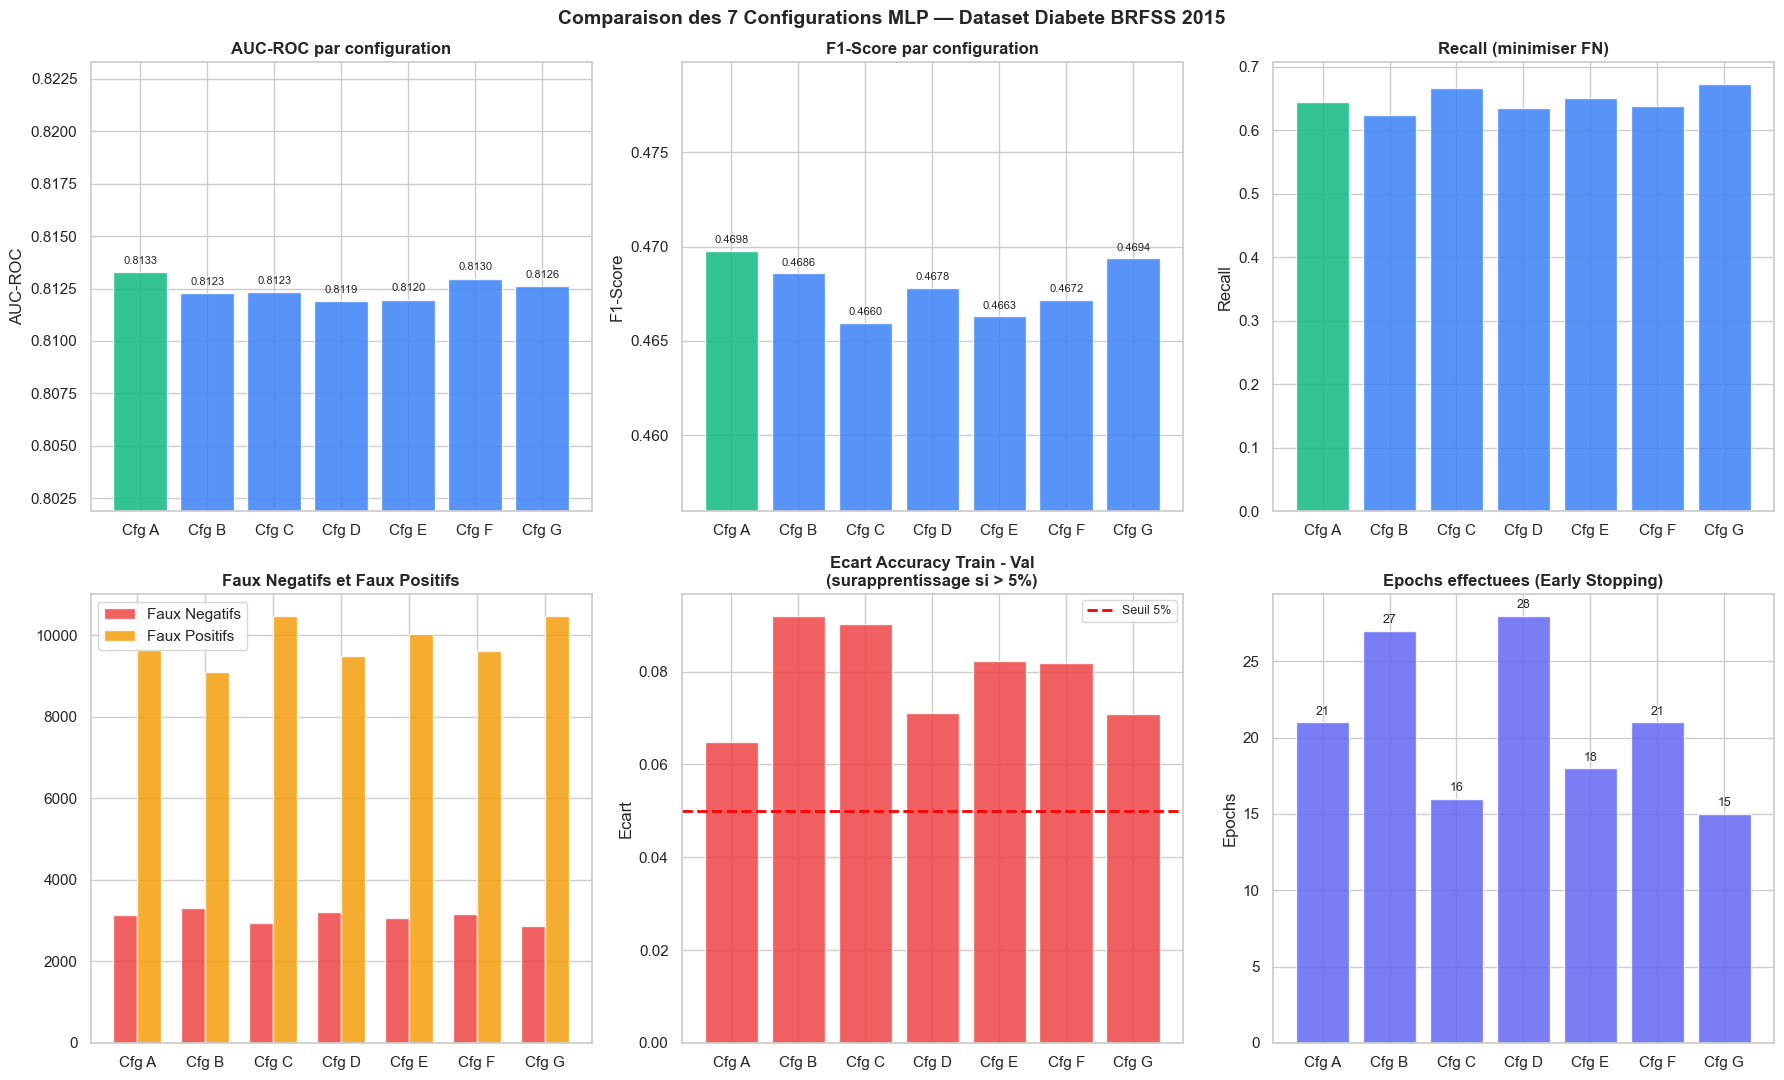

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

configs = [r['config'] for r in resultats]
labels_courts = [f"Cfg {'ABCDEFG'[i]}" for i in range(len(configs))]

# Couleurs : vert pour le meilleur AUC
aucs   = [r['auc']      for r in resultats]
f1s    = [r['f1']       for r in resultats]
recalls= [r['recall']   for r in resultats]
fns    = [r['fn']       for r in resultats]
fps    = [r['fp']       for r in resultats]
ecarts = [r['ecart_acc']for r in resultats]

best_idx = int(np.argmax(aucs))
colors   = ['#10B981' if i == best_idx else '#3B82F6' for i in range(len(configs))]

# 1. AUC-ROC
bars = axes[0,0].bar(labels_courts, aucs, color=colors, alpha=0.85, edgecolor='white')
axes[0,0].set_title('AUC-ROC par configuration', fontweight='bold')
axes[0,0].set_ylabel('AUC-ROC')
axes[0,0].set_ylim([min(aucs)-0.01, max(aucs)+0.01])
for bar, val in zip(bars, aucs):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, val + 0.0003,
                   f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# 2. F1-score
bars2 = axes[0,1].bar(labels_courts, f1s, color=colors, alpha=0.85, edgecolor='white')
axes[0,1].set_title('F1-Score par configuration', fontweight='bold')
axes[0,1].set_ylabel('F1-Score')
axes[0,1].set_ylim([min(f1s)-0.01, max(f1s)+0.01])
for bar, val in zip(bars2, f1s):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, val + 0.0003,
                   f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# 3. Recall
axes[0,2].bar(labels_courts, recalls, color=colors, alpha=0.85, edgecolor='white')
axes[0,2].set_title('Recall (minimiser FN)', fontweight='bold')
axes[0,2].set_ylabel('Recall')

# 4. FN et FP
x = np.arange(len(configs))
w = 0.35
axes[1,0].bar(x - w/2, fns, w, label='Faux Negatifs', color='#EF4444', alpha=0.85)
axes[1,0].bar(x + w/2, fps, w, label='Faux Positifs', color='#F59E0B', alpha=0.85)
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(labels_courts)
axes[1,0].set_title('Faux Negatifs et Faux Positifs', fontweight='bold')
axes[1,0].legend()

# 5. Ecart train-val (diagnostic overfitting)
ecart_colors = ['#10B981' if e < 0.03 else '#F59E0B' if e < 0.06 else '#EF4444'
                for e in ecarts]
axes[1,1].bar(labels_courts, ecarts, color=ecart_colors, alpha=0.85, edgecolor='white')
axes[1,1].axhline(y=0.05, color='red', lw=2, linestyle='--', label='Seuil 5%')
axes[1,1].set_title('Ecart Accuracy Train - Val\n(surapprentissage si > 5%)', fontweight='bold')
axes[1,1].set_ylabel('Ecart')
axes[1,1].legend(fontsize=9)

# 6. Epochs (Early Stopping)
epochs_list = [r['epochs'] for r in resultats]
axes[1,2].bar(labels_courts, epochs_list, color='#6366F1', alpha=0.85, edgecolor='white')
axes[1,2].set_title('Epochs effectuees (Early Stopping)', fontweight='bold')
axes[1,2].set_ylabel('Epochs')
for bar, val in zip(axes[1,2].patches, epochs_list):
    axes[1,2].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                   str(val), ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparaison des 7 Configurations MLP — Dataset Diabete BRFSS 2015',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


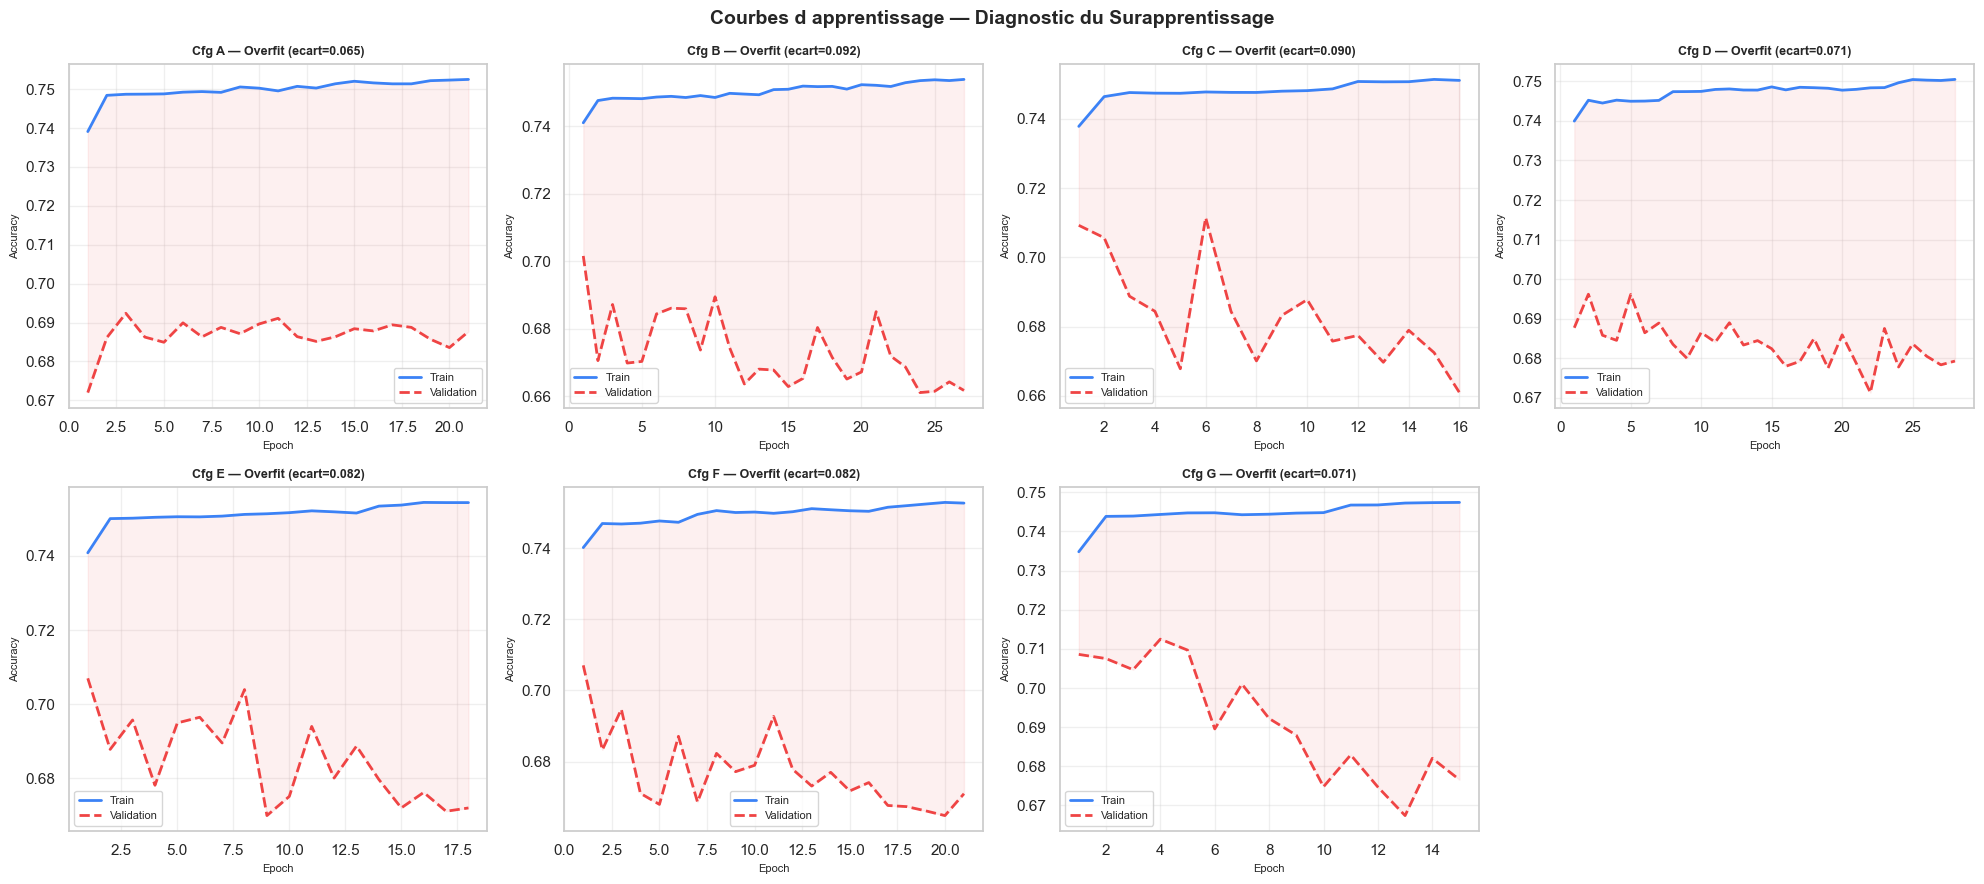

In [17]:
# Courbes d'apprentissage — toutes les configurations
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, r in enumerate(resultats):
    h = r['history'].history
    ep = range(1, len(h['loss']) + 1)
    axes[i].plot(ep, h['accuracy'],     lw=2, color='#3B82F6', label='Train')
    axes[i].plot(ep, h['val_accuracy'], lw=2, color='#EF4444', linestyle='--', label='Validation')
    axes[i].fill_between(ep, h['accuracy'], h['val_accuracy'], alpha=0.08, color='#EF4444')
    ecart = h['accuracy'][-1] - h['val_accuracy'][-1]
    status = 'OK' if ecart < 0.05 else 'Overfit'
    axes[i].set_title(f"Cfg {'ABCDEFG'[i]} — {status} (ecart={ecart:.3f})", fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Epoch', fontsize=8)
    axes[i].set_ylabel('Accuracy', fontsize=8)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

# Cacher le dernier subplot si impair
if len(resultats) < len(axes):
    for j in range(len(resultats), len(axes)):
        axes[j].set_visible(False)

plt.suptitle('Courbes d apprentissage — Diagnostic du Surapprentissage',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 7. Analyse du Meilleur Modele

On identifie la configuration avec le meilleur AUC-ROC  
et on l'analyse en detail : matrice de confusion, courbe ROC, rapport de classification.


In [18]:
# Identification du meilleur modele
best = max(resultats, key=lambda r: r['auc'])
print(f'Meilleur modele : {best["config"]}')
print(f'  AUC-ROC    : {best["auc"]:.4f}')
print(f'  F1         : {best["f1"]:.4f}')
print(f'  Recall     : {best["recall"]:.4f}')
print(f'  Precision  : {best["precision"]:.4f}')
print(f'  Accuracy   : {best["accuracy"]:.4f}')
print(f'  FN         : {best["fn"]:,}')
print(f'  FP         : {best["fp"]:,}')
print(f'  Epochs     : {best["epochs"]}')
print(f'  Parametres : {best["n_params"]:,}')
print()
print('Rapport de classification complet :')
y_pred_best = (best['y_proba'] >= 0.5).astype(int)
print(classification_report(y_test, y_pred_best,
      target_names=['Non-diabetique', 'Diabetique']))


Meilleur modele : Config A — 1 couche
  AUC-ROC    : 0.8133
  F1         : 0.4698
  Recall     : 0.6439
  Precision  : 0.3698
  Accuracy   : 0.7777
  FN         : 3,124
  FP         : 9,630
  Epochs     : 21
  Parametres : 1,729

Rapport de classification complet :
                precision    recall  f1-score   support

Non-diabetique       0.93      0.80      0.86     48595
    Diabetique       0.37      0.64      0.47      8774

      accuracy                           0.78     57369
     macro avg       0.65      0.72      0.66     57369
  weighted avg       0.84      0.78      0.80     57369



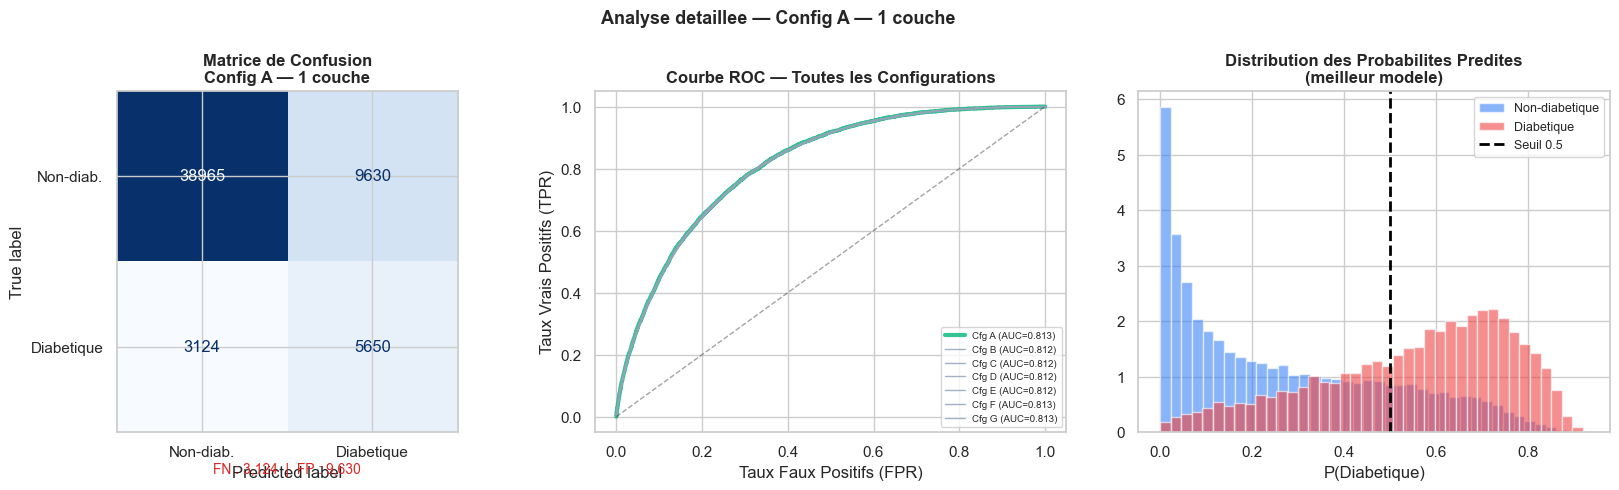

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Matrice de confusion
cm_best = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm_best, display_labels=['Non-diab.', 'Diabetique'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matrice de Confusion\n{best["config"]}', fontweight='bold')
axes[0].text(0.5, -0.12,
             f'FN : {cm_best[1,0]:,}  |  FP : {cm_best[0,1]:,}',
             transform=axes[0].transAxes, ha='center',
             color='#DC2626', fontsize=10)

# 2. Courbe ROC — tous les modeles superposes
for i, r in enumerate(resultats):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    lw  = 3 if r['config'] == best['config'] else 1
    col = '#10B981' if r['config'] == best['config'] else '#94A3B8'
    axes[1].plot(fpr, tpr, lw=lw, color=col, alpha=0.85,
                 label=f"Cfg {'ABCDEFG'[i]} (AUC={r['auc']:.3f})")
axes[1].plot([0,1],[0,1],'k--', lw=1, alpha=0.4)
axes[1].set_title('Courbe ROC — Toutes les Configurations', fontweight='bold')
axes[1].set_xlabel('Taux Faux Positifs (FPR)')
axes[1].set_ylabel('Taux Vrais Positifs (TPR)')
axes[1].legend(fontsize=7, loc='lower right')

# 3. Distribution des probabilites predites
axes[2].hist(best['y_proba'][y_test == 0], bins=40, alpha=0.6,
             color='#3B82F6', label='Non-diabetique', density=True)
axes[2].hist(best['y_proba'][y_test == 1], bins=40, alpha=0.6,
             color='#EF4444', label='Diabetique', density=True)
axes[2].axvline(x=0.5, color='black', lw=2, linestyle='--', label='Seuil 0.5')
axes[2].set_title('Distribution des Probabilites Predites\n(meilleur modele)', fontweight='bold')
axes[2].set_xlabel('P(Diabetique)')
axes[2].legend(fontsize=9)

plt.suptitle(f'Analyse detaillee — {best["config"]}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# Resume final : tableau de classement complet
print('Resume final — classement des configurations')
print('=' * 80)
df_final = df_res[[
    'Configuration', 'Couches', 'Batch size', 'Dropout',
    'Parametres', 'Epochs', 'AUC-ROC', 'F1', 'Recall', 'FN', 'Ecart train-val'
]].copy()
df_final.index = range(1, len(df_final)+1)
df_final.index.name = 'Rang'
print(df_final.to_string())
print()
best_row = df_final.iloc[0]
print(f'Modele retenu : {best_row["Configuration"]}')
print(f'  -> AUC-ROC  : {best_row["AUC-ROC"]}')
print(f'  -> F1       : {best_row["F1"]}')
print(f'  -> Recall   : {best_row["Recall"]}')
print(f'  -> FN       : {int(best_row["FN"]):,} malades non detectes')


Resume final — classement des configurations
                           Configuration  Couches  Batch size  Dropout  Parametres  Epochs  AUC-ROC      F1  Recall    FN  Ecart train-val
Rang                                                                                                                                      
1                    Config A — 1 couche        1          64      0.3        1729      21   0.8133  0.4698  0.6439  3124           0.0649
2            Config F — 2 couches larges        2          64      0.4       40193      21   0.8130  0.4672  0.6387  3170           0.0818
3     Config G — 3 couches dropout eleve        3          32      0.4       14081      15   0.8126  0.4694  0.6729  2870           0.0708
4          Config C — 3 couches standard        3          64      0.3       14081      16   0.8123  0.4660  0.6665  2926           0.0902
5          Config B — 2 couches standard        2          64      0.3       11905      27   0.8123  0.4686  0.6231  3307